# AISO 실험 — 어떤 문제에서 효과적인가?

## 실험 구조
| Part | 내용 |
|---|---|
| A | **AISO 변형 4종** — 동적β / PD행렬 / 동적α / 풀콤보 |
| B | **추가 벤치마크** — Schwefel / Griewank / 제한예산 / 노이즈 |
| C | **종합 히트맵** — 알고리즘×조건 순위표로 홈그라운드 확정 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

N_AGENTS = 30
N_ITER   = 200
ALPHA    = 0.3
BETA     = 0.1
N_RUNS   = 5
SEEDS    = [42, 123, 777, 2024, 31415]

PSO_W, PSO_C1, PSO_C2 = 0.729, 1.494, 1.494
FA_BETA0, FA_GAMMA, FA_ALPHA_FA = 1.0, 1.0, 0.2
DE_F, DE_CR = 0.8, 0.9

COLORS = {
    'AISO':       '#DD8452',
    'AISO_DynB':  '#E8A87C',
    'AISO_PD':    '#B5651D',
    'AISO_DynA':  '#FF6B35',
    'AISO_Full':  '#8B0000',
    'PSO':        '#4C72B0',
    'Firefly':    '#C44E52',
    'DE':         '#55A868',
    'Random':     '#8C8C8C',
}
print('설정 완료')

설정 완료


In [2]:

# ================================================================
# 기준 알고리즘들
# ================================================================
def run_pso(f, K, seed=42, n_iter=N_ITER):
    np.random.seed(seed)
    X=np.random.rand(N_AGENTS,K).astype(np.float32); V=np.zeros_like(X)
    S=np.array([f(X[i]) for i in range(N_AGENTS)])
    pX=X.copy(); pS=S.copy(); bX=X[np.argmax(S)].copy(); bS=float(S.max()); curve=[bS]
    for _ in range(n_iter):
        r1=np.random.rand(N_AGENTS,K).astype(np.float32)
        r2=np.random.rand(N_AGENTS,K).astype(np.float32)
        V=PSO_W*V+PSO_C1*r1*(pX-X)+PSO_C2*r2*(bX-X); X=np.clip(X+V,0,1)
        S=np.array([f(X[i]) for i in range(N_AGENTS)])
        upd=S>pS; pX[upd]=X[upd]; pS[upd]=S[upd]
        if pS.max()>bS: bS=float(pS.max()); bX=pX[np.argmax(pS)].copy()
        curve.append(bS)
    return bS, curve

def run_firefly(f, K, seed=42, n_iter=N_ITER):
    np.random.seed(seed)
    X=np.random.rand(N_AGENTS,K).astype(np.float32)
    S=np.array([f(X[i]) for i in range(N_AGENTS)]); bS=float(S.max()); curve=[bS]
    for _ in range(n_iter):
        for i in range(N_AGENTS):
            for j in range(N_AGENTS):
                if S[j]<=S[i]: continue
                beta=FA_BETA0*np.exp(-FA_GAMMA*float(np.sum((X[i]-X[j])**2)))
                nX=np.clip(X[i]+beta*(X[j]-X[i])+FA_ALPHA_FA*(np.random.rand(K).astype(np.float32)-0.5),0,1)
                ns=f(nX)
                if ns>S[i]: X[i]=nX; S[i]=ns
        if S.max()>bS: bS=float(S.max())
        curve.append(bS)
    return bS, curve

def run_de(f, K, seed=42, n_iter=N_ITER):
    np.random.seed(seed)
    X=np.random.rand(N_AGENTS,K).astype(np.float32)
    S=np.array([f(X[i]) for i in range(N_AGENTS)]); bS=float(S.max()); curve=[bS]
    idx_all=np.arange(N_AGENTS)
    for _ in range(n_iter):
        for i in range(N_AGENTS):
            cands=idx_all[idx_all!=i]; a,b,c=cands[np.random.choice(len(cands),3,replace=False)]
            mutant=np.clip(X[a]+DE_F*(X[b]-X[c]),0,1)
            cross=np.random.rand(K)<DE_CR
            if not cross.any(): cross[np.random.randint(K)]=True
            trial=np.where(cross,mutant,X[i]).astype(np.float32); ns=f(trial)
            if ns>S[i]: X[i]=trial; S[i]=ns
        if S.max()>bS: bS=float(S.max())
        curve.append(bS)
    return bS, curve

def run_random(f, K, seed=42, n_iter=N_ITER):
    np.random.seed(seed)
    bS=float(max(f(np.random.rand(K).astype(np.float32)) for _ in range(N_AGENTS))); curve=[bS]
    for _ in range(n_iter):
        bS=max(bS,float(max(f(np.random.rand(K).astype(np.float32)) for _ in range(N_AGENTS)))); curve.append(bS)
    return bS, curve

print('기준 알고리즘 완료')


기준 알고리즘 완료


In [3]:
# ================================================================
# Part A — AISO 변형 4종
# ================================================================
def make_M(K, M_type, seed):
    np.random.seed(seed)
    if M_type == 'random':
        return np.random.uniform(0, 2, (K, K)).astype(np.float32)
    elif M_type == 'posdef':
        A = np.random.randn(K, K).astype(np.float32)
        M = (A @ A.T) / K
        return (M / (M.mean() + 1e-8)).astype(np.float32)  # mean ≈ 1
    elif M_type == 'sparse':
        M = np.random.uniform(0, 2, (K, K)).astype(np.float32)
        M[np.random.rand(K, K) < 0.6] = 0
        return M


def run_aiso_variant(f, K, seed=42, n_iter=N_ITER,
                     beta_mode='fixed',    # 'fixed' | 'linear' | 'exp'
                     alpha_mode='fixed',   # 'fixed' | 'linear'
                     M_type='random'):     # 'random' | 'posdef' | 'sparse'
    np.random.seed(seed)
    M  = make_M(K, M_type, seed)
    np.random.seed(seed + 1000)  # re-seed after M creation
    aX = np.random.rand(N_AGENTS, K).astype(np.float32)
    aW = np.random.dirichlet(np.ones(K), N_AGENTS).astype(np.float32)
    aS = np.array([f(aX[i]) for i in range(N_AGENTS)])
    bX = aX[np.argmax(aS)].copy(); bS = float(aS.max())
    curve = [bS]

    for t in range(n_iter):
        if   beta_mode  == 'fixed':   beta_t  = BETA
        elif beta_mode  == 'linear':  beta_t  = 0.4  - 0.39  * t / n_iter
        elif beta_mode  == 'exp':     beta_t  = 0.4  * np.exp(-4 * t / n_iter)

        if   alpha_mode == 'fixed':   alpha_t = ALPHA
        elif alpha_mode == 'linear':  alpha_t = 0.5  - 0.4   * t / n_iter

        for i in range(N_AGENTS):
            j  = np.random.choice([k for k in range(N_AGENTS) if k != i])
            c  = float(aW[i] @ M @ aW[j])
            nX = np.clip(aX[i] + alpha_t * c * (aX[j] - aX[i]), 0, 1)
            ns = f(nX)
            if ns > aS[i]:
                aX[i] = nX; aS[i] = ns
                aW[i] = (1 - beta_t) * aW[i] + beta_t * aW[j]
                aW[i] /= aW[i].sum()
        if aS.max() > bS: bS = float(aS.max()); bX = aX[np.argmax(aS)].copy()
        curve.append(bS)

    return bS, curve


# 변형 정의
AISO_VARIANTS = {
    'AISO':      dict(beta_mode='fixed',  alpha_mode='fixed',  M_type='random'),
    'AISO_DynB': dict(beta_mode='linear', alpha_mode='fixed',  M_type='random'),
    'AISO_PD':   dict(beta_mode='fixed',  alpha_mode='fixed',  M_type='posdef'),
    'AISO_DynA': dict(beta_mode='fixed',  alpha_mode='linear', M_type='random'),
    'AISO_Full': dict(beta_mode='linear', alpha_mode='linear', M_type='posdef'),
}

print('AISO 변형 5종 정의 완료')
for name, cfg in AISO_VARIANTS.items():
    print(f'  {name:<12}: {cfg}')

AISO 변형 5종 정의 완료
  AISO        : {'beta_mode': 'fixed', 'alpha_mode': 'fixed', 'M_type': 'random'}
  AISO_DynB   : {'beta_mode': 'linear', 'alpha_mode': 'fixed', 'M_type': 'random'}
  AISO_PD     : {'beta_mode': 'fixed', 'alpha_mode': 'fixed', 'M_type': 'posdef'}
  AISO_DynA   : {'beta_mode': 'fixed', 'alpha_mode': 'linear', 'M_type': 'random'}
  AISO_Full   : {'beta_mode': 'linear', 'alpha_mode': 'linear', 'M_type': 'posdef'}


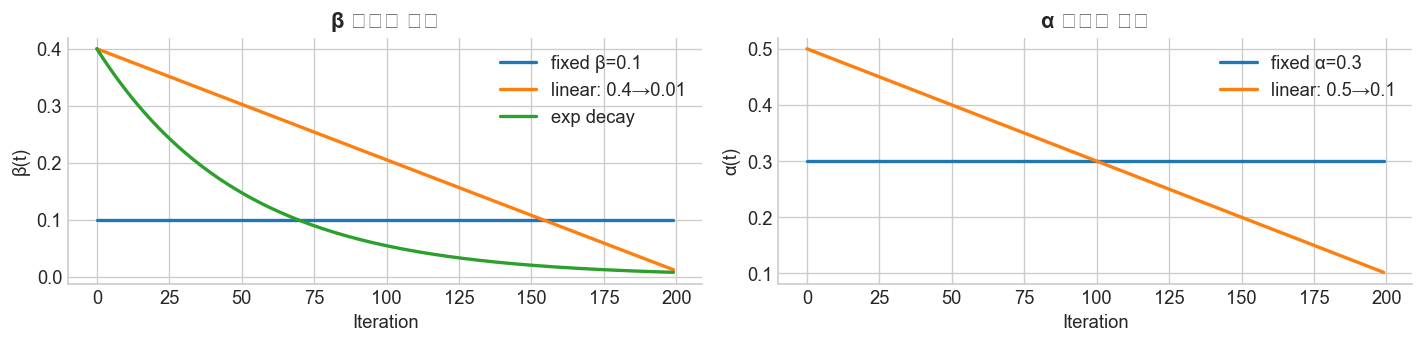

In [4]:
# β 스케줄 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
t = np.arange(N_ITER)
axes[0].plot(t, np.full_like(t, BETA, dtype=float), label='fixed β=0.1', lw=2)
axes[0].plot(t, 0.4 - 0.39*t/N_ITER, label='linear: 0.4→0.01', lw=2)
axes[0].plot(t, 0.4*np.exp(-4*t/N_ITER), label='exp decay', lw=2)
axes[0].set_title('β 스케줄 비교', fontweight='bold')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('β(t)')
axes[0].legend(frameon=False)

axes[1].plot(t, np.full_like(t, ALPHA, dtype=float), label='fixed α=0.3', lw=2)
axes[1].plot(t, 0.5 - 0.4*t/N_ITER, label='linear: 0.5→0.1', lw=2)
axes[1].set_title('α 스케줄 비교', fontweight='bold')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('α(t)')
axes[1].legend(frameon=False)

plt.tight_layout(); plt.savefig('exp_schedules.png', bbox_inches='tight'); plt.show()


--- Rastrigin K=20 ---
  AISO         mean=-101.528
  AISO_DynB    mean=-105.408
  AISO_PD      mean=-94.102
  AISO_DynA    mean=-107.579
  AISO_Full    mean=-107.960

--- Rosenbrock K=20 ---
  AISO         mean=-99.877
  AISO_DynB    mean=-99.807
  AISO_PD      mean=-110.239
  AISO_DynA    mean=-121.324
  AISO_Full    mean=-115.660


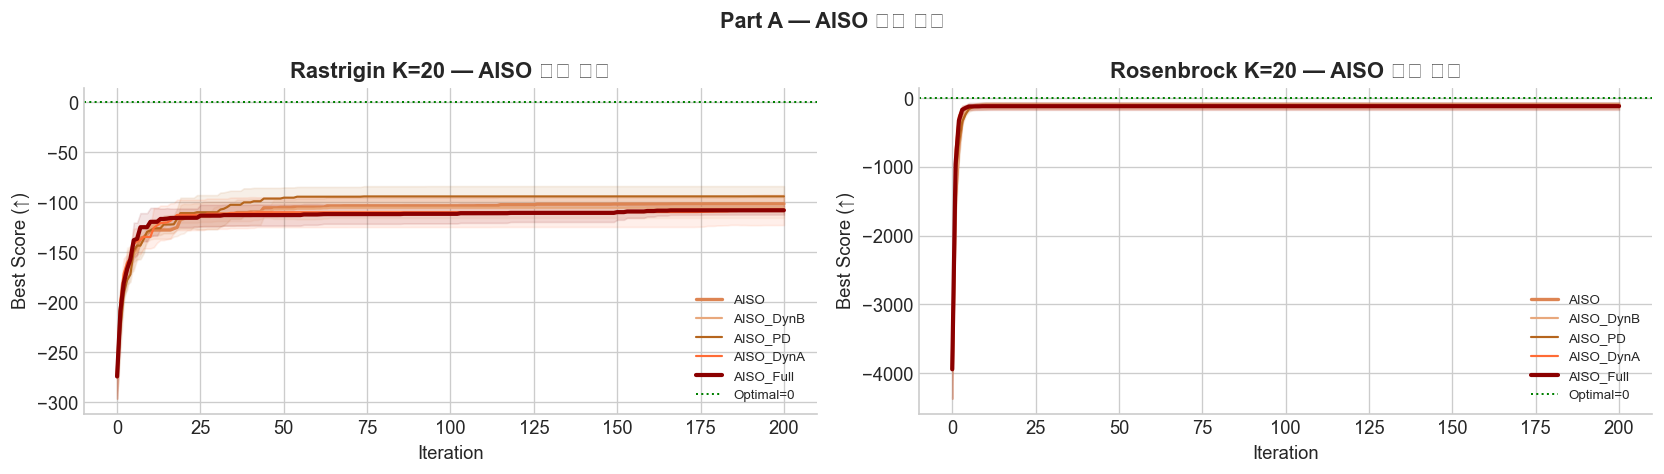

In [5]:
# AISO 변형 × Rastrigin + Rosenbrock
def make_rastrigin(K, A=10):
    def f(X): x=X*10.24-5.12; return -(A*K+np.sum(x**2-A*np.cos(2*np.pi*x)))
    return f

def make_rosenbrock(K):
    def f(X): x=X*4.0-2.0; return -np.sum(100*(x[1:]-x[:-1]**2)**2+(1-x[:-1])**2)
    return f

K = 20
bench_fns = [('Rastrigin', make_rastrigin(K)), ('Rosenbrock', make_rosenbrock(K))]

variant_results = {}  # (bench_name, variant_name) → list of scores
variant_curves  = {}  # (bench_name, variant_name) → list of curves

for bname, f in bench_fns:
    print(f'\n--- {bname} K={K} ---')
    for vname, cfg in AISO_VARIANTS.items():
        scores, curves = [], []
        for seed in SEEDS[:N_RUNS]:
            s, c = run_aiso_variant(f, K, seed=seed, **cfg)
            scores.append(s); curves.append(c)
        variant_results[(bname, vname)] = scores
        variant_curves[(bname, vname)]  = curves
        print(f'  {vname:<12} mean={np.mean(scores):.3f}')

# 수렴 곡선 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (bname, _) in zip(axes, bench_fns):
    for vname in AISO_VARIANTS:
        cv  = variant_curves[(bname, vname)]
        arr = np.array(cv); mean = arr.mean(0); std = arr.std(0)
        x   = np.arange(len(mean))
        lw  = 2.5 if vname == 'AISO_Full' else (2.0 if vname == 'AISO' else 1.3)
        ax.plot(x, mean, color=COLORS[vname], lw=lw, label=vname)
        ax.fill_between(x, mean-std, mean+std, alpha=0.1, color=COLORS[vname])
    ax.axhline(0, color='green', ls=':', lw=1.2, label='Optimal=0')
    ax.set_title(f'{bname} K={K} — AISO 변형 비교', fontweight='bold')
    ax.set_xlabel('Iteration'); ax.set_ylabel('Best Score (↑)')
    ax.legend(frameon=False, fontsize=8)

plt.suptitle('Part A — AISO 변형 실험', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('exp_variants.png', bbox_inches='tight'); plt.show()

---
## Part B — 추가 벤치마크 & 조건 실험

| 실험 | 목적 |
|---|---|
| **Schwefel** | 전역 최솟값이 탐색 공간 끝쪽에 숨어 있음 — 탐색 범위 테스트 |
| **Griewank** | Rastrigin보다 부드러운 multimodal — 중간 난이도 |
| **제한 예산** (N_ITER=20) | GNN처럼 평가가 비쌀 때 시뮬레이션 |
| **노이즈 fitness** (σ=2) | 평가 결과에 잡음 — 보수적 업데이트 규칙 테스트 |

추가 벤치마크 함수 4개 준비 완료
2D 지형 시각화...


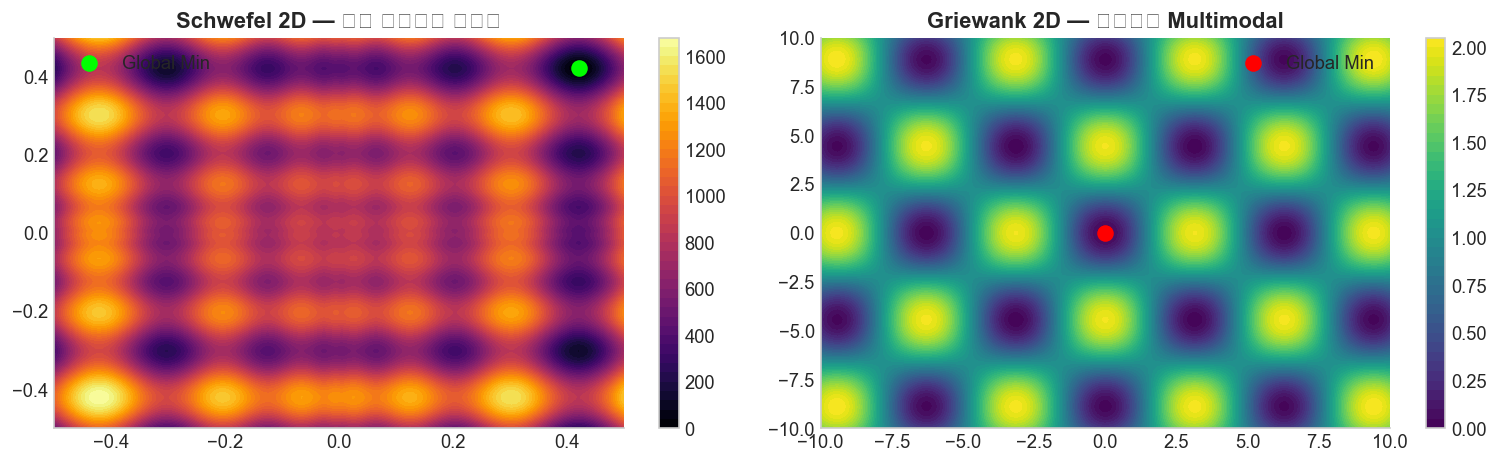

In [6]:
# ── 추가 벤치마크 함수 정의 ──────────────────────────────────
def make_schwefel(K):
    # x ∈ [-500, 500], global min = 0 at x_i = 420.9687
    lo, hi = -500.0, 500.0
    def f(X):
        x = X * (hi - lo) + lo
        return -(418.9829 * K - np.sum(x * np.sin(np.sqrt(np.abs(x)))))
    return f

def make_griewank(K):
    # x ∈ [-600, 600], global min = 0 at x=0
    lo, hi = -600.0, 600.0
    def f(X):
        x   = X * (hi - lo) + lo
        s   = np.sum(x**2) / 4000
        p   = np.prod(np.cos(x / np.sqrt(np.arange(1, K+1))))
        return -(s - p + 1)
    return f

def make_noisy(base_f, sigma=2.0):
    def f(X): return base_f(X) + np.random.normal(0, sigma)
    return f

K = 20
BENCHMARKS = {
    'Rastrigin':      make_rastrigin(K),
    'Rosenbrock':     make_rosenbrock(K),
    'Schwefel':       make_schwefel(K),
    'Griewank':       make_griewank(K),
    'Noisy_Ras(σ=2)': make_noisy(make_rastrigin(K), sigma=2.0),
}

# best AISO variant (will be updated after Part A results)
BEST_VARIANT_CFG = AISO_VARIANTS['AISO_Full']  # placeholder

BASE_RUNNERS = [
    ('PSO',     lambda f,K,seed,ni: run_pso(f,K,seed,ni)),
    ('Firefly', lambda f,K,seed,ni: run_firefly(f,K,seed,ni)),
    ('DE',      lambda f,K,seed,ni: run_de(f,K,seed,ni)),
    ('Random',  lambda f,K,seed,ni: run_random(f,K,seed,ni)),
]

print('추가 벤치마크 함수 4개 준비 완료')
print('2D 지형 시각화...')

# Schwefel + Griewank 2D 지형
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
grid = np.linspace(-500, 500, 300)
xx, yy = np.meshgrid(grid, grid)
zz_s = 418.9829*2 - (xx*np.sin(np.sqrt(np.abs(xx))) + yy*np.sin(np.sqrt(np.abs(yy))))
im = axes[0].contourf(xx/1000, yy/1000, zz_s, levels=50, cmap='inferno')
axes[0].scatter([420.9687/1000], [420.9687/1000], color='lime', s=80, zorder=5, label='Global Min')
axes[0].set_title('Schwefel 2D — 전역 최솟값이 끝쪽에', fontweight='bold')
axes[0].legend(frameon=False); plt.colorbar(im, ax=axes[0])

grid2 = np.linspace(-10, 10, 300)
xx2, yy2 = np.meshgrid(grid2, grid2)
zz_g = (xx2**2+yy2**2)/4000 - np.cos(xx2)*np.cos(yy2/np.sqrt(2)) + 1
im2 = axes[1].contourf(xx2, yy2, zz_g, levels=50, cmap='viridis')
axes[1].scatter([0],[0], color='red', s=80, zorder=5, label='Global Min')
axes[1].set_title('Griewank 2D — 부드러운 Multimodal', fontweight='bold')
axes[1].legend(frameon=False); plt.colorbar(im2, ax=axes[1])

plt.tight_layout(); plt.savefig('exp_new_landscapes.png', bbox_inches='tight'); plt.show()

In [7]:
# ── 전체 실험 실행: 5 벤치마크 × (AISO 원본 + 변형 + PSO/FA/DE/Random) ──
# 주의: Firefly는 O(N²)이라 느림 — 전체 N_ITER=200 실행

ALL_RESULTS = {}  # (bench, alg) → mean_score

for bname, f_fn in BENCHMARKS.items():
    print(f'\n=== {bname} ===')

    # AISO 변형들
    for vname, cfg in AISO_VARIANTS.items():
        scores = [run_aiso_variant(f_fn, K, seed=s, **cfg)[0] for s in SEEDS[:N_RUNS]]
        ALL_RESULTS[(bname, vname)] = np.mean(scores)
        print(f'  {vname:<14} {np.mean(scores):.3f}')

    # 기준 알고리즘들
    for aname, runner in BASE_RUNNERS:
        scores = [runner(f_fn, K, s, N_ITER)[0] for s in SEEDS[:N_RUNS]]
        ALL_RESULTS[(bname, aname)] = np.mean(scores)
        print(f'  {aname:<14} {np.mean(scores):.3f}')

print('\n전체 실험 완료')


=== Rastrigin ===
  AISO           -101.528
  AISO_DynB      -105.408
  AISO_PD        -94.102
  AISO_DynA      -107.579
  AISO_Full      -107.960
  PSO            -43.528
  Firefly        -87.196
  DE             -174.463
  Random         -210.768

=== Rosenbrock ===
  AISO           -99.877
  AISO_DynB      -99.807
  AISO_PD        -110.239
  AISO_DynA      -121.324
  AISO_Full      -115.660
  PSO            -41.451
  Firefly        -46.210
  DE             -221.009
  Random         -1506.344

=== Schwefel ===
  AISO           -6360.553
  AISO_DynB      -6370.239
  AISO_PD        -6223.929
  AISO_DynA      -6389.810
  AISO_Full      -6195.596
  PSO            -1662.925
  Firefly        -4995.188
  DE             -4127.063
  Random         -5343.120

=== Griewank ===
  AISO           -17.481
  AISO_DynB      -17.516
  AISO_PD        -19.474
  AISO_DynA      -21.810
  AISO_Full      -20.591
  PSO            -0.194
  Firefly        -8.330
  DE             -22.485
  Random         -203.

In [8]:
# ── 제한 예산 실험 (N_ITER=20) ────────────────────────────────
N_ITER_LIM = 20
LIM_RESULTS = {}

print(f'제한 예산 N_ITER={N_ITER_LIM} 실험...')
for bname, f_fn in [('Rastrigin', BENCHMARKS['Rastrigin']),
                    ('Rosenbrock', BENCHMARKS['Rosenbrock']),
                    ('Schwefel', BENCHMARKS['Schwefel'])]:
    print(f'  {bname}')
    for vname, cfg in AISO_VARIANTS.items():
        scores = [run_aiso_variant(f_fn, K, seed=s, n_iter=N_ITER_LIM, **cfg)[0] for s in SEEDS[:N_RUNS]]
        LIM_RESULTS[(bname, vname)] = np.mean(scores)
    for aname, runner in BASE_RUNNERS:
        scores = [runner(f_fn, K, s, N_ITER_LIM)[0] for s in SEEDS[:N_RUNS]]
        LIM_RESULTS[(bname, aname)] = np.mean(scores)

print('완료')

제한 예산 N_ITER=20 실험...
  Rastrigin
  Rosenbrock
  Schwefel
완료


---
## Part C — 종합 히트맵: 알고리즘 × 조건별 순위

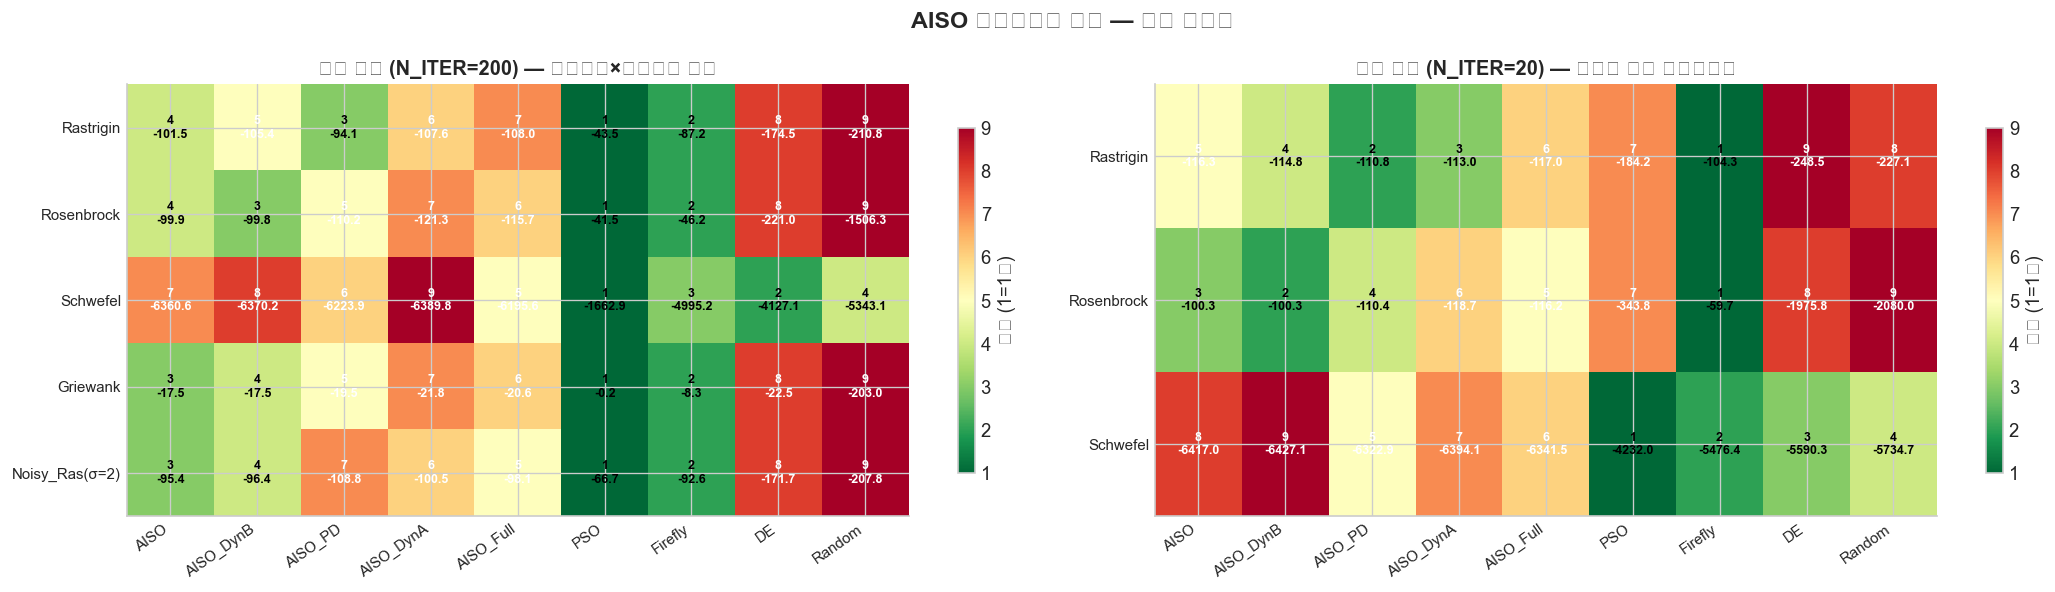


평균 순위 (전체 예산)
알고리즘               평균순위      1등횟수
-----------------------------------
AISO               4.20         0
AISO_DynB          4.80         0
AISO_PD            5.20         0
AISO_DynA          7.00         0
AISO_Full          5.80         0
PSO                1.00         5
Firefly            2.20         0
DE                 6.80         0
Random             8.00         0

평균 순위 (제한 예산)
알고리즘               평균순위      1등횟수
-----------------------------------
AISO               5.33         0
AISO_DynB          5.00         0
AISO_PD            3.67         0
AISO_DynA          5.33         0
AISO_Full          5.67         0
PSO                5.00         1
Firefly            1.33         2
DE                 6.67         0
Random             7.00         0


In [9]:
ALG_ORDER   = ['AISO', 'AISO_DynB', 'AISO_PD', 'AISO_DynA', 'AISO_Full', 'PSO', 'Firefly', 'DE', 'Random']
BENCH_ORDER = list(BENCHMARKS.keys())
LIM_BENCHES = ['Rastrigin', 'Rosenbrock', 'Schwefel']

def make_rank_matrix(results_dict, bench_list, alg_list):
    """각 벤치마크에서 알고리즘 순위(1=1등)를 반환"""
    rank_mat = np.zeros((len(bench_list), len(alg_list)))
    score_mat = np.zeros_like(rank_mat)
    for bi, b in enumerate(bench_list):
        scores = [results_dict.get((b, a), np.nan) for a in alg_list]
        score_mat[bi] = scores
        valid = [(s, i) for i, s in enumerate(scores) if not np.isnan(s)]
        ranked = sorted(valid, key=lambda x: x[0], reverse=True)
        for rank, (_, idx) in enumerate(ranked):
            rank_mat[bi, idx] = rank + 1
    return rank_mat, score_mat


rank_full, score_full = make_rank_matrix(ALL_RESULTS,  BENCH_ORDER, ALG_ORDER)
rank_lim,  score_lim  = make_rank_matrix(LIM_RESULTS,  LIM_BENCHES, ALG_ORDER)

# ── 히트맵 시각화 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

def draw_heatmap(ax, rank_mat, score_mat, bench_list, alg_list, title):
    n_alg = len(alg_list)
    cmap  = plt.cm.RdYlGn_r  # 1등(초록)→꼴찌(빨강)
    im    = ax.imshow(rank_mat, cmap=cmap, vmin=1, vmax=n_alg, aspect='auto')
    ax.set_xticks(range(n_alg)); ax.set_xticklabels(alg_list, rotation=35, ha='right', fontsize=9)
    ax.set_yticks(range(len(bench_list))); ax.set_yticklabels(bench_list, fontsize=9)
    for bi in range(len(bench_list)):
        for ai in range(n_alg):
            r = int(rank_mat[bi, ai])
            s = score_mat[bi, ai]
            text = f'{r}\n{s:.1f}'
            color = 'white' if r > n_alg // 2 else 'black'
            ax.text(ai, bi, text, ha='center', va='center', fontsize=7.5, color=color, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=12)
    plt.colorbar(im, ax=ax, label='순위 (1=1등)', shrink=0.8)

draw_heatmap(axes[0], rank_full, score_full, BENCH_ORDER, ALG_ORDER,
             f'전체 예산 (N_ITER={N_ITER}) — 알고리즘×벤치마크 순위')
draw_heatmap(axes[1], rank_lim,  score_lim,  LIM_BENCHES, ALG_ORDER,
             f'제한 예산 (N_ITER={N_ITER_LIM}) — 고비용 환경 시뮬레이션')

plt.suptitle('AISO 홈그라운드 탐색 — 순위 히트맵', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.savefig('exp_heatmap.png', bbox_inches='tight'); plt.show()


# ── 평균 순위 요약 ────────────────────────────────────────────
print('\n평균 순위 (전체 예산)')
print(f'{"알고리즘":<14} {"평균순위":>8}  {"1등횟수":>8}')
print('-'*35)
for ai, alg in enumerate(ALG_ORDER):
    avg_rank = rank_full[:, ai].mean()
    n_first  = (rank_full[:, ai] == 1).sum()
    print(f'{alg:<14} {avg_rank:>8.2f}  {n_first:>8}')

print('\n평균 순위 (제한 예산)')
print(f'{"알고리즘":<14} {"평균순위":>8}  {"1등횟수":>8}')
print('-'*35)
for ai, alg in enumerate(ALG_ORDER):
    avg_rank = rank_lim[:, ai].mean()
    n_first  = (rank_lim[:, ai] == 1).sum()
    print(f'{alg:<14} {avg_rank:>8.2f}  {n_first:>8}')

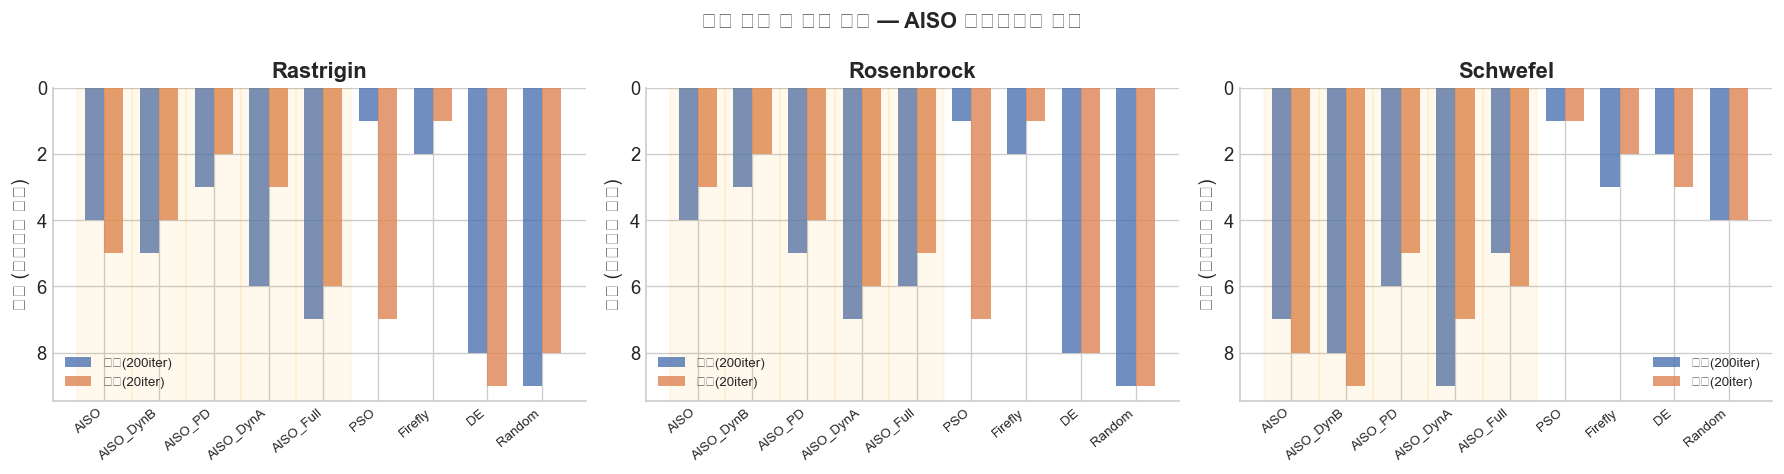

In [10]:
# ── 제한예산 vs 전체예산 순위 변화 ────────────────────────────
# 예산 줄이면 AISO 순위가 올라가는지 확인

fig, axes = plt.subplots(1, len(LIM_BENCHES), figsize=(15, 4))

for ax, (bi, bname) in zip(axes, enumerate(LIM_BENCHES)):
    bench_idx_full = BENCH_ORDER.index(bname)

    ranks_full = rank_full[bench_idx_full]
    ranks_lim  = rank_lim[bi]

    x = np.arange(len(ALG_ORDER))
    w = 0.35
    b1 = ax.bar(x - w/2, ranks_full, w, label=f'전체({N_ITER}iter)', color='#4C72B0', alpha=0.8)
    b2 = ax.bar(x + w/2, ranks_lim,  w, label=f'제한({N_ITER_LIM}iter)', color='#DD8452', alpha=0.8)
    ax.set_title(bname, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(ALG_ORDER, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('순위 (낮을수록 좋음)')
    ax.invert_yaxis()
    ax.legend(frameon=False, fontsize=8)

    # AISO 계열 표시
    for xi, alg in enumerate(ALG_ORDER):
        if 'AISO' in alg:
            ax.axvspan(xi-0.5, xi+0.5, alpha=0.07, color='orange')

plt.suptitle('예산 제한 시 순위 변화 — AISO 홈그라운드 확인', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('exp_budget_comparison.png', bbox_inches='tight'); plt.show()